# GP Occupancy Raycasting for Visibility-Aware Navigation

### Joost Leliveld, update: 23-03-2026

This notebook presents the **whole story** of the current navigation stack, from camera projection and nonlinear observation modeling to GP-based occlusion handling and EFE planning.

The aim is not only to show the method, but to make it possible to judge whether the method is a good decision.

We will follow one line of reasoning:

1. **Navigation stack**: robot dynamics, camera observations, and the probabilistic state-space model.
2. **Gaussian approximations**: what stays Gaussian, what becomes nonlinear, and where ET-style approximations enter.
3. **Occlusion handling**: old 2D GP baseline, 2.5D ray-opacity prior, and online correction.
4. **Planning influence**: how visibility changes the effective observation model and therefore the EFE objective.
5. **Decision**: what is strong, what is approximate, and what belongs in future work.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'scripts' / 'gp_occupancy_raycasting_visual_helpers.py').exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('Could not locate repository root containing scripts/gp_occupancy_raycasting_visual_helpers.py')
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scripts.gp_occupancy_raycasting_visual_helpers as helper

RUN_MODE = 'full'
SEED = 12

np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.2

/home/joostleliveld/UnembodiedNavigation/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Use case

A mobile robot moves on a planar floor and is observed by a static external camera.  
The planner should move the robot toward a goal while preferring states from which the robot remains observable.

The occlusion question is therefore not separate from planning.  
It changes the observation model, and through that it changes the EFE objective.

The two box variants in this notebook share the same footprint but have different heights. This is intentional: it gives us a clean way to test whether the occlusion model is really sensitive to 3D ray geometry or only to 2D footprint structure.


### Dynamics (differential-drive / unicycle model)

We use the unicycle state and control variables

$$
 z_k = 
 \begin{bmatrix}
 x_k \\ y_k \\ \theta_k
 \end{bmatrix},
 \qquad
 u_k = 
 \begin{bmatrix}
 v_k \\ \omega_k
 \end{bmatrix}.
$$

The discrete-time dynamics are

$$
\begin{aligned}
 x_k &= x_{k-1} + v_k \Delta t \cos(\theta_{k-1}) \\
 y_k &= y_{k-1} + v_k \Delta t \sin(\theta_{k-1}) \\
 \theta_k &= \theta_{k-1} + \omega_k \Delta t
\end{aligned}
\qquad +\; q_k,
$$

with white process noise

$$
 q_k \sim \mathcal{N}(0,Q).
$$

So the latent navigation problem is already probabilistic before we say anything about visibility.


### Observations: external oblique camera (pixels)

A static camera observes one target point on the robot body. The measurement is the pixel location

$$
 o_k \triangleq 
 \begin{bmatrix}
 u_k^{\mathrm{pix}} \\ v_k^{\mathrm{pix}}
 \end{bmatrix}.
$$

The observation model is

$$
 o_k = g(z_k) + r_k,
 \qquad r_k \sim \mathcal{N}(0,R).
$$

The mapping $g(z_k)$ is nonlinear because it is built from projective camera geometry:

1. embed the ground-plane robot point into 3D,
2. transform world coordinates to camera coordinates,
3. divide by depth $Z_c$,
4. map normalized image coordinates to pixels with the camera intrinsics.

This gives a pixel observation model of the form

$$
 g(z_k) =
 \begin{bmatrix}
 f_x \dfrac{X_c(z_k)}{Z_c(z_k)} + c_x \\
 f_y \dfrac{Y_c(z_k)}{Z_c(z_k)} + c_y
 \end{bmatrix}.
$$

The perspective division by $Z_c$ is the core nonlinearity.


### Probabilistic model

The navigation stack is therefore described by the nonlinear state-space model

$$
\begin{aligned}
 p(z_0) &= \mathcal{N}(z_0 \mid m_0, S_0), \\
 p(z_k \mid z_{k-1}, u_k) &= \mathcal{N}(z_k \mid f(z_{k-1},u_k), Q), \\
 p(o_k \mid z_k) &= \mathcal{N}(o_k \mid g(z_k), R).
\end{aligned}
$$

Here:

- $f(\cdot)$ is the unicycle transition model,
- $g(\cdot)$ is the nonlinear camera projection,
- $Q$ is process noise,
- $R$ is observation noise.

This is the baseline stack before occlusion handling is added.


### Gaussian approximation to likelihood

Because $g(\cdot)$ is nonlinear, the likelihood is not Gaussian as a function of the state.  
The stack therefore works with a Gaussian approximation to the joint state-observation distribution:

$$
 p(o_k, z_k)
 \approx
 \mathcal{N}
 \left(
 \begin{bmatrix} z_k \\ o_k \end{bmatrix}
 \Bigg| 
 \begin{bmatrix} m_k \\ \mu_k \end{bmatrix},
 \begin{bmatrix}
 S_k & \Gamma_k \\
 \Gamma_k^\top & \Sigma_k
 \end{bmatrix}
 \right).
$$

The notebook stack uses Taylor-style moment approximations:

- **ET1**: first-order expansion of $g(\cdot)$,
- **ET2**: second-order expansion of $g(\cdot)$.

So the Gaussian story is exact for the process noise and prior, but approximate for the nonlinear camera observation.

This point matters later, because the visibility-aware planner is not operating on a perfectly linear-Gaussian model. It is operating on a **nonlinear observation model with Gaussian moment approximations**.


In [2]:
ctx = helper.build_context(seed=SEED, run_mode=RUN_MODE)
probe_summary_df = ctx['probe_summary_df']
planning_cfg = ctx['variants']['Tall box']['planning']['cfg']
planning_cfg_df = pd.Series(vars(planning_cfg), name='value').rename_axis('parameter').reset_index()
display(probe_summary_df)
display(planning_cfg_df)

Precomputing prior beta=1.0: Tall box: 100%|██████████| 6561/6561 [00:01<00:00, 3467.31it/s]


,scene,probe,oracle,old_gp,new_mean_only,new_uncertainty_aware,opacity_uncertainty_aware
0,Short box,start,1.00,0.908259,0.976806,0.955957,0.045042
1,Short box,pre-occ,1.00,0.933927,0.990696,0.983668,0.016467
2,Short box,shadow,0.02,0.256198,0.320959,0.315403,1.156584
3,Short box,deep-shadow,1.00,0.317587,0.904130,0.874962,0.133711
4,Short box,goal,1.00,0.859949,0.982443,0.966794,0.033770
5,Tall box,start,1.00,0.908259,0.950538,0.911753,0.092386
6,Tall box,pre-occ,1.00,0.933927,0.978469,0.966353,0.034226
7,Tall box,shadow,0.02,0.256198,0.195498,0.184934,1.692363
8,Tall box,deep-shadow,0.02,0.317587,0.225469,0.208298,1.572246
9,Tall box,goal,1.00,0.859949,0.960420,0.928275,0.074429


,parameter,value
0,dt,0.2
1,horizon,18
2,n_steps,90
3,q_rho_xy,0.01
4,q_exec_xy,0.03
5,q_exec_theta,0.08
6,r_visible_uv,2.5
7,r_miss_uv,420.0
8,goal_prior_u_std_start,80.0
9,goal_prior_v_std_start,80.0


## Scene and oracle visibility

The planner state remains 2D, but the oracle visibility test is geometric and 3D-feasible:

- 3D camera pose,
- 2D obstacle footprint,
- obstacle height,
- target point on the robot body,
- hard segment-vs-box intersection along the camera-target ray.

This defines the oracle visibility field $O_{\mathrm{true}}(x)$.

The start state has been placed further from the occluded region so the later planner comparison reads as a route-choice problem rather than immediate hovering near the shadow boundary.


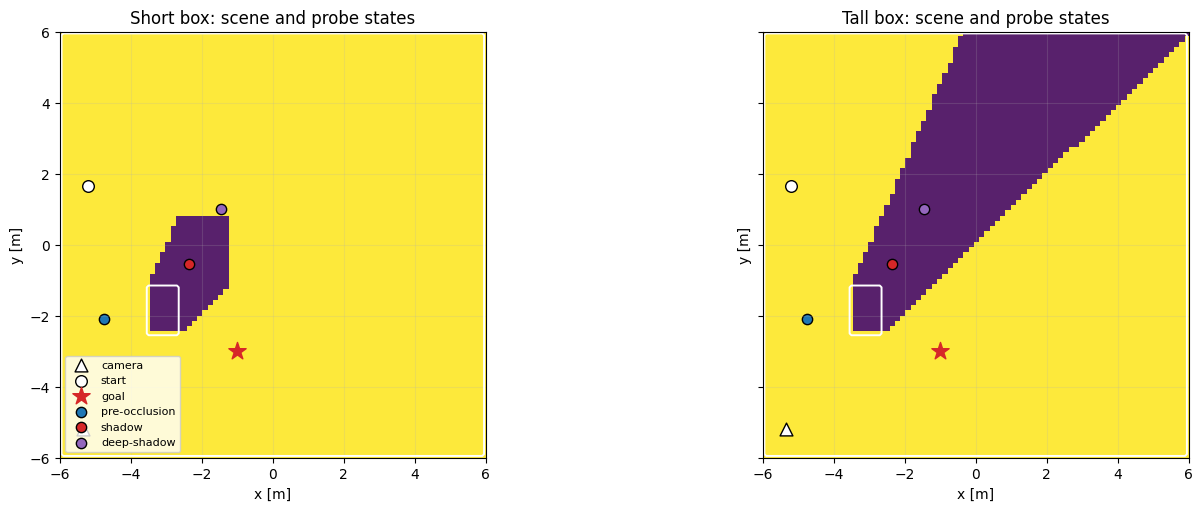

In [3]:
fig = helper.plot_scene_overview(ctx)
plt.show()

### Shared GP field

The GP field is shared between the short-box and tall-box scenes.

That means the GP itself is **not** where the height difference lives.  
The learned field captures horizontal opacity structure, while the 3D ray geometry determines how much of that horizontal field matters for a given box height.

This separation is useful for interpretation:

- what is learned by the GP,
- what is imposed by the ray geometry,
- and what is later corrected online.


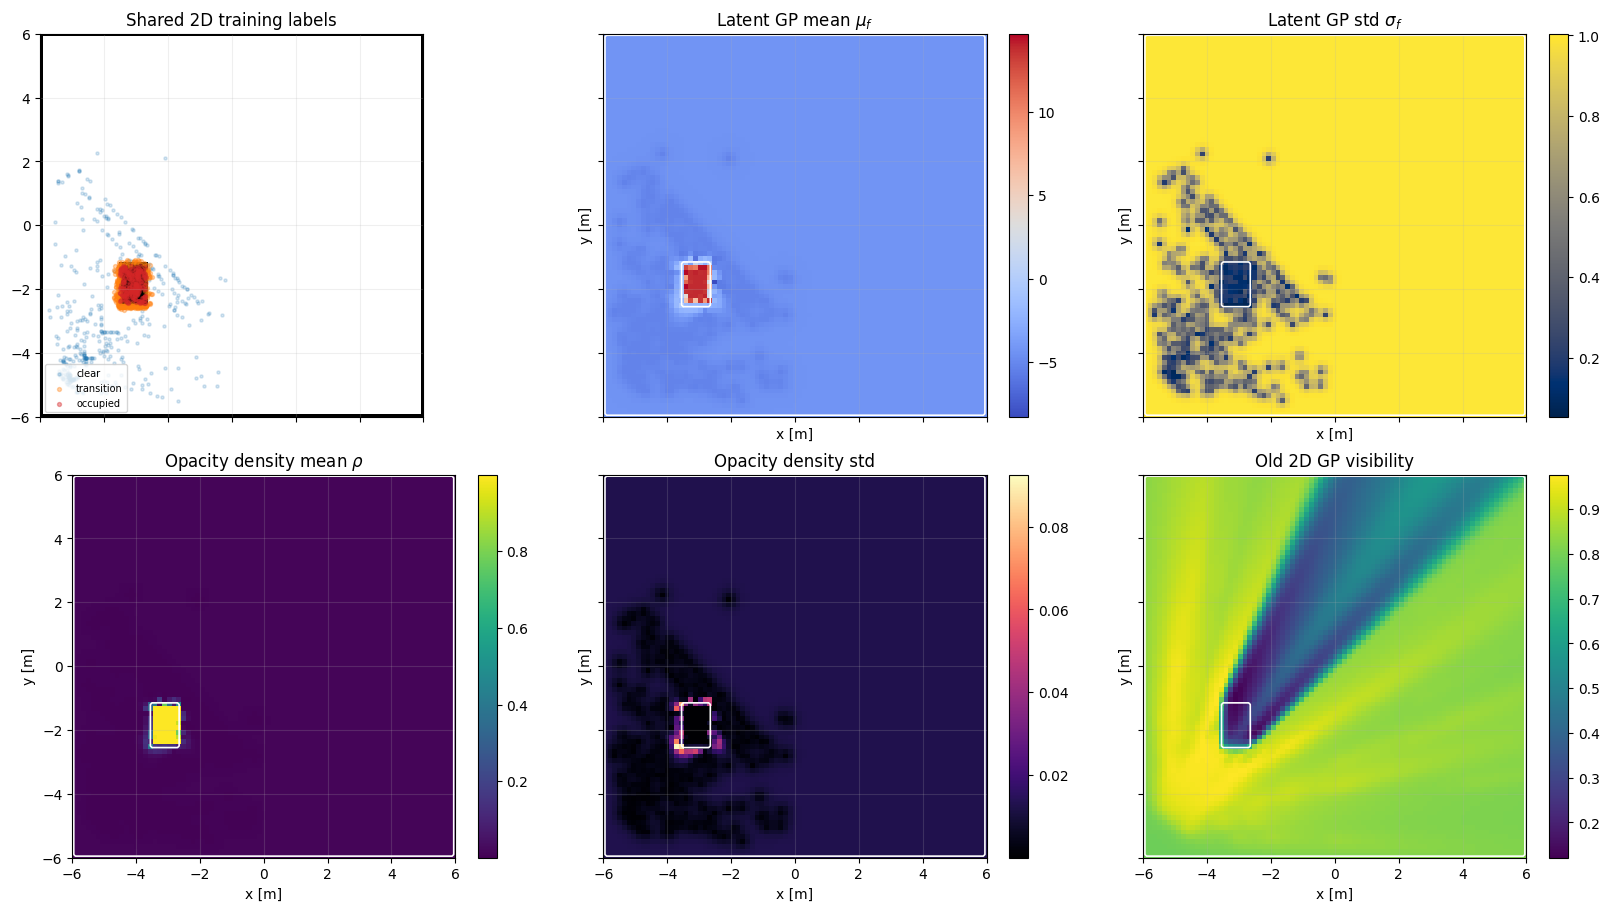

In [4]:
fig = helper.plot_shared_gp_field(ctx)
plt.show()

## Occlusion handling: from old 2D GP to 2.5D ray-opacity prior

### Old 2D GP baseline

The historical baseline builds a 2D occupancy-like GP field and then defines visibility as

$$
 O_{\mathrm{old}}(x)
 =
 \exp\!\left(
 -\tau \cdot \frac{1}{N}
 \sum_{i=1}^{N} p_{\mathrm{occ}}(x_i,y_i)
 \right).
$$

This is simple, but it has an important limitation:

> if two obstacles share the same footprint, the old baseline sees them as the same object.

So the old baseline can produce a shadow-like effect, but it cannot truly distinguish short and tall boxes.

### New 2.5D ray-opacity prior

The newer prior keeps the GP on the ground plane but performs visibility computation along a **3D camera-target ray**.

The clean interpretation is to treat the GP as Gaussian in a **latent opacity variable** $f(x)$ and define a conservative opacity summary in latent space:

$$
 \rho_{\mathrm{cons},i}
 =
 \sigma\!\big(\mu_{f,i} + \beta\sigma_{f,i}\big).
$$

For each sampled ray point we then compute

$$
 \Delta A_i
 =
 \Delta s_i\, g(z_i)\, \rho_{\mathrm{cons},i},
$$

and accumulate

$$
 A_0(x) = \sum_i \Delta A_i,
 \qquad
 O_0(x) = \exp(-A_0(x)).
$$

This is the central modeling decision of the notebook.

The current helper implementation still uses the first-order proxy $\rho_{\mathrm{mean},i} + \beta\rho_{\mathrm{std},i}$, which should be read as the local linearization of the latent-space construction above rather than as a separate probabilistic model.


## Raycasting geometry

The next plots explain where the 2.5D behavior comes from.

The important conceptual split is:

- the GP provides a **horizontal opacity tendency**,
- the ray geometry provides a **vertical compatibility test**,
- the line integral turns local opacity into visibility.

So the method is not a full 3D GP occupancy map. It is a structured decomposition of the problem into a learned horizontal field and a geometric ray-height interaction.


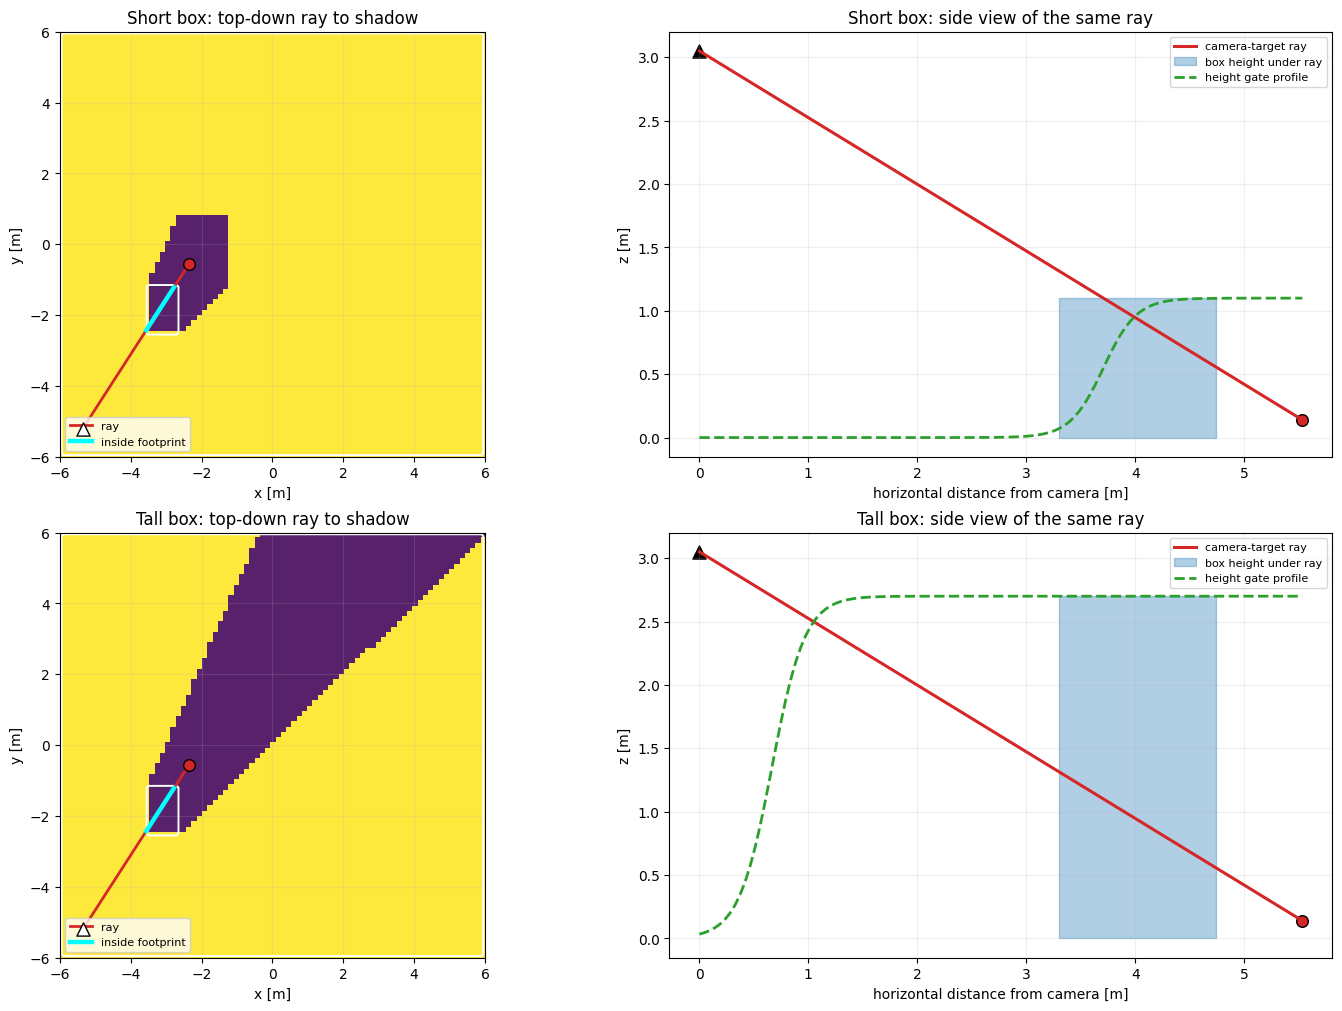

In [5]:
fig = helper.plot_raycasting_probe(ctx, probe_name='shadow')
plt.show()

### Hard versus soft height gate

The height gate tells us whether a ray sample is low enough to be blocked by an obstacle of this height.

Hard version:

$$
 g_{\mathrm{hard}}(z_i) = \mathbb{1}[z_i \le z_{\mathrm{box,top}}].
$$

Soft version used in the notebook:

$$
 g(z_i)
 =
 \sigma\!\left(
 \frac{z_{\mathrm{box,top}} - z_i}{\tau_z}
 \right).
$$

This gate is **not** itself an occupancy map. It is only a height-based compatibility factor.

That distinction matters:

- the gate may turn on before the obstacle footprint is reached,
- but local opacity remains small there unless the horizontal GP field is also high.

So the gate tells us **where the ray is low enough for obstacle material to matter**, not where the obstacle definitely is.


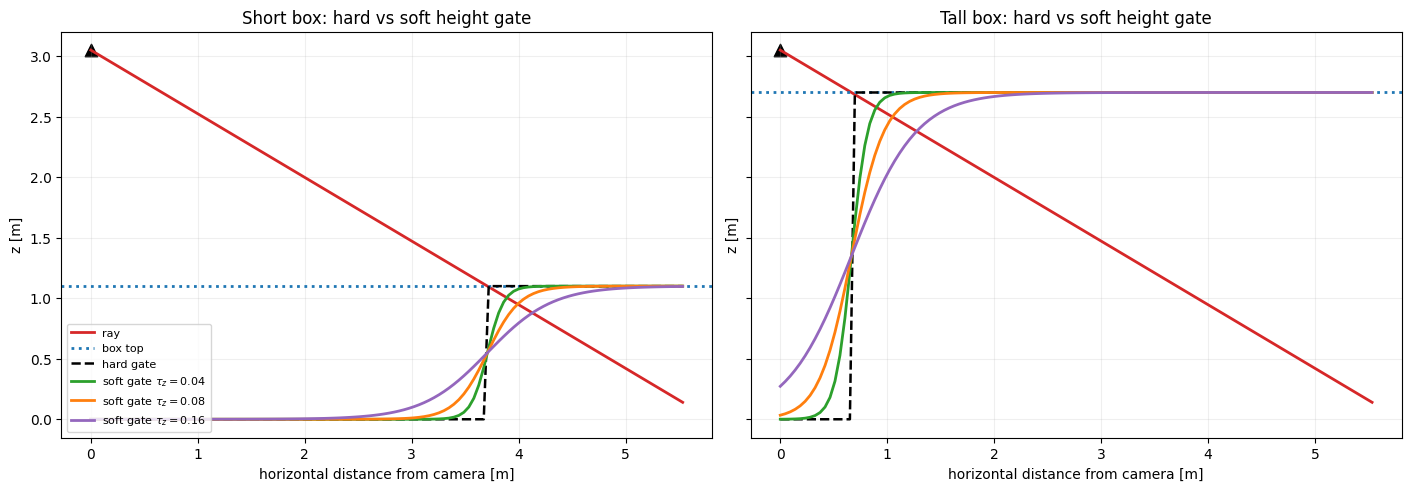

In [6]:
fig = helper.plot_height_gate_family(ctx, probe_name='shadow')
plt.show()

### One-ray decomposition

Along a single ray, the method applies the following transformation chain:

1. query the latent GP mean and variance on the ground plane,
2. build a conservative latent opacity summary,
3. apply the height gate,
4. accumulate local opacity into ray opacity,
5. exponentiate to obtain visibility.

This is the right place to think about linear versus nonlinear transformations.

### What stays linear

If we work at the latent GP level,

$$
 \mathbf{f}_S \sim \mathcal{N}(\mu_S, K_S),
 \qquad
 a_f(x) = \mathbf{w}^\top \mathbf{f}_S,
$$

then $a_f(x)$ is still Gaussian because it is a linear transform of a Gaussian vector.

This is why the uncertainty-aware prior is cleanest in latent space:

$$
 \rho_{\mathrm{cons}}(x) = \sigma\!\big(\mu_f(x) + \beta\sigma_f(x)\big).
$$

The older output-space form $\rho_{\mathrm{mean}} + \beta\rho_{\mathrm{std}}$ is only the first-order Taylor view of this construction.

### What becomes nonlinear

The notebook introduces three nonlinear operations:

- sigmoid to convert latent values into opacity-density summaries,
- sigmoid-based height gate,
- exponential to convert ray opacity into visibility.

So the final visibility is **not Gaussian**.  
The method is therefore best understood as a Gaussian latent model followed by nonlinear approximations, with the most defensible conservative prior defined before the sigmoid rather than after it.


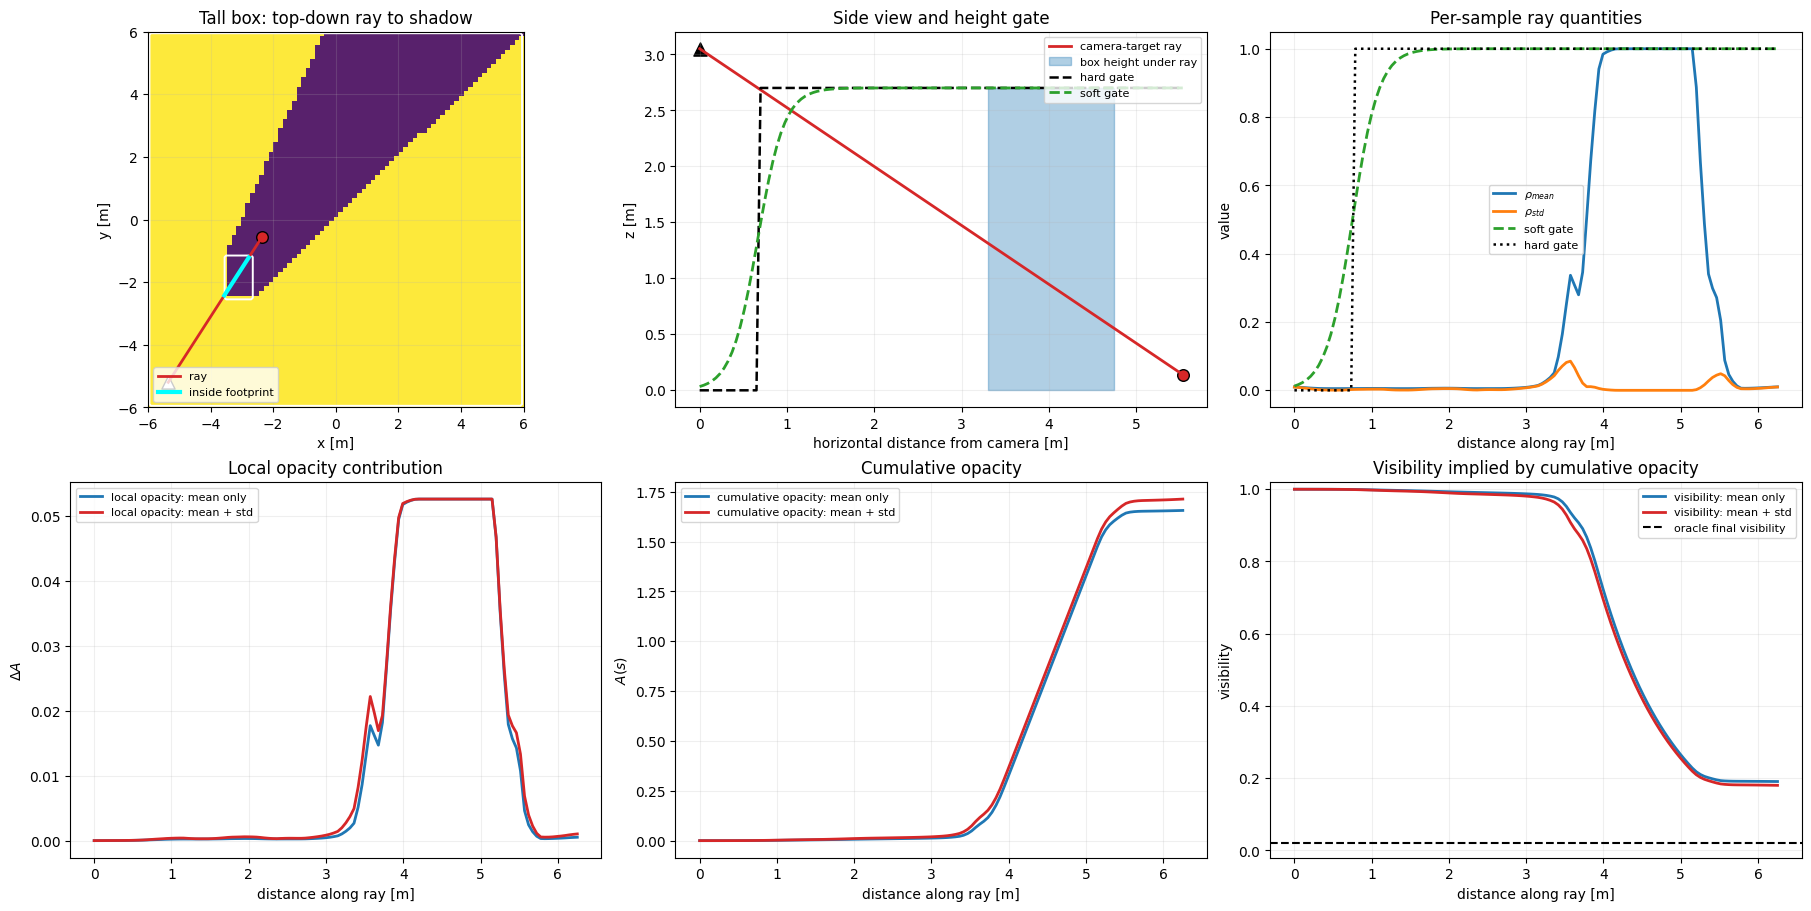

In [7]:
fig = helper.plot_ray_decomposition(ctx, variant_name='Tall box', probe_name='shadow')
plt.show()

## Map-level comparison

At map level we compare four objects:

1. oracle visibility,
2. old 2D GP visibility,
3. 2.5D offline prior,
4. uncertainty-aware 2.5D prior.

The map comparison should be read with one question in mind:

> Does the method reproduce the correct shadow direction and relative scale, even if it does not match the hard oracle exactly?

For planning, that question matters more than pixel-perfect agreement with the oracle.


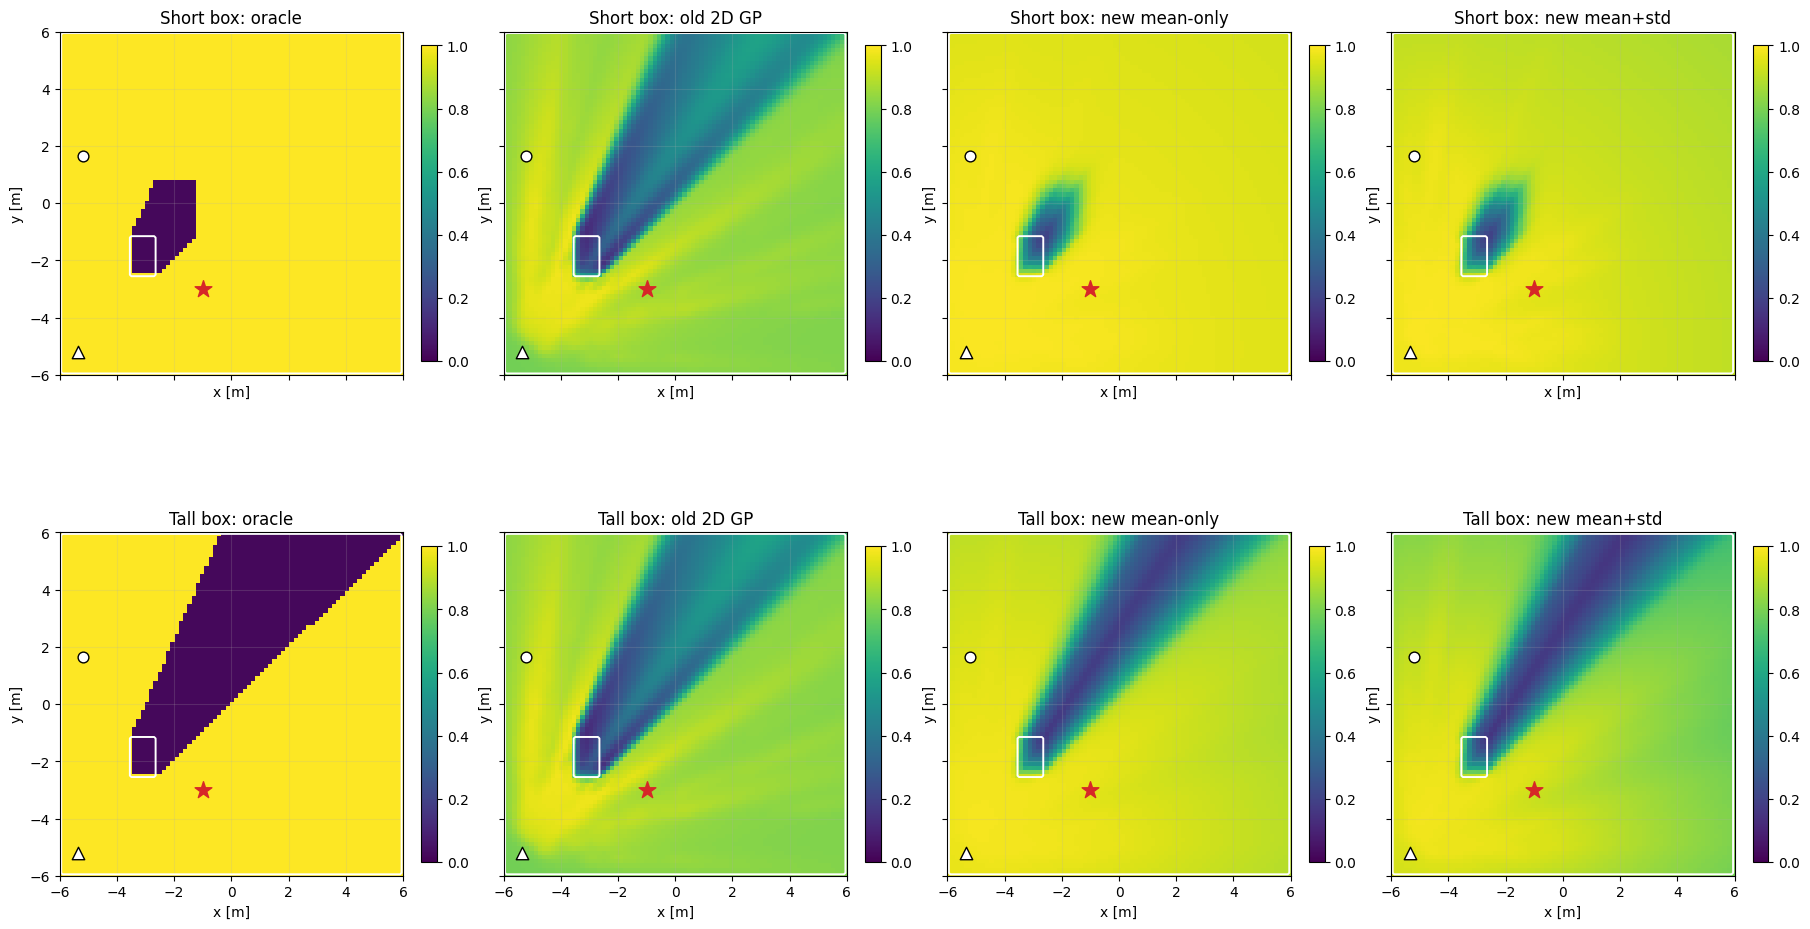

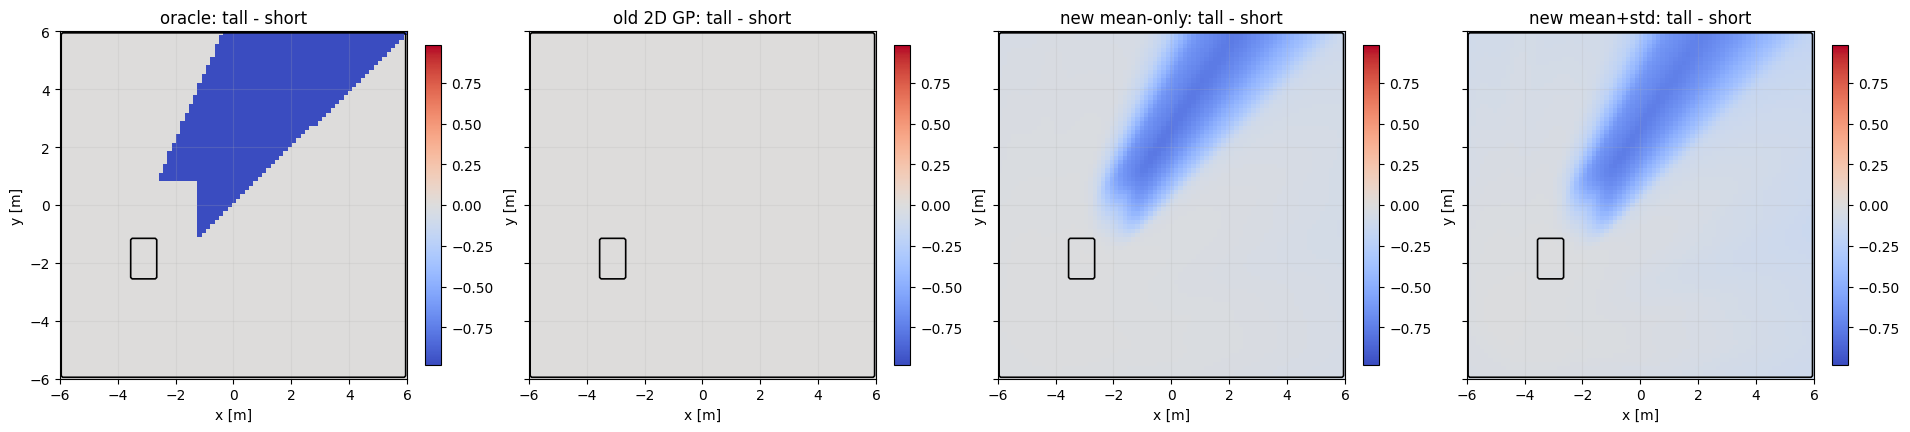

In [8]:
fig = helper.plot_method_maps(ctx)
plt.show()

fig = helper.plot_height_difference_maps(ctx)
plt.show()

## Visible-to-shadow profile

A 1D corridor profile is often easier to interpret than a 2D heatmap.

It shows how quickly each method transitions from clear visibility to shadowed visibility as the robot moves toward the occluded region.

This is particularly useful when evaluating whether the prior is:

- too smooth,
- too sharp,
- too pessimistic,
- or insensitive to obstacle height.


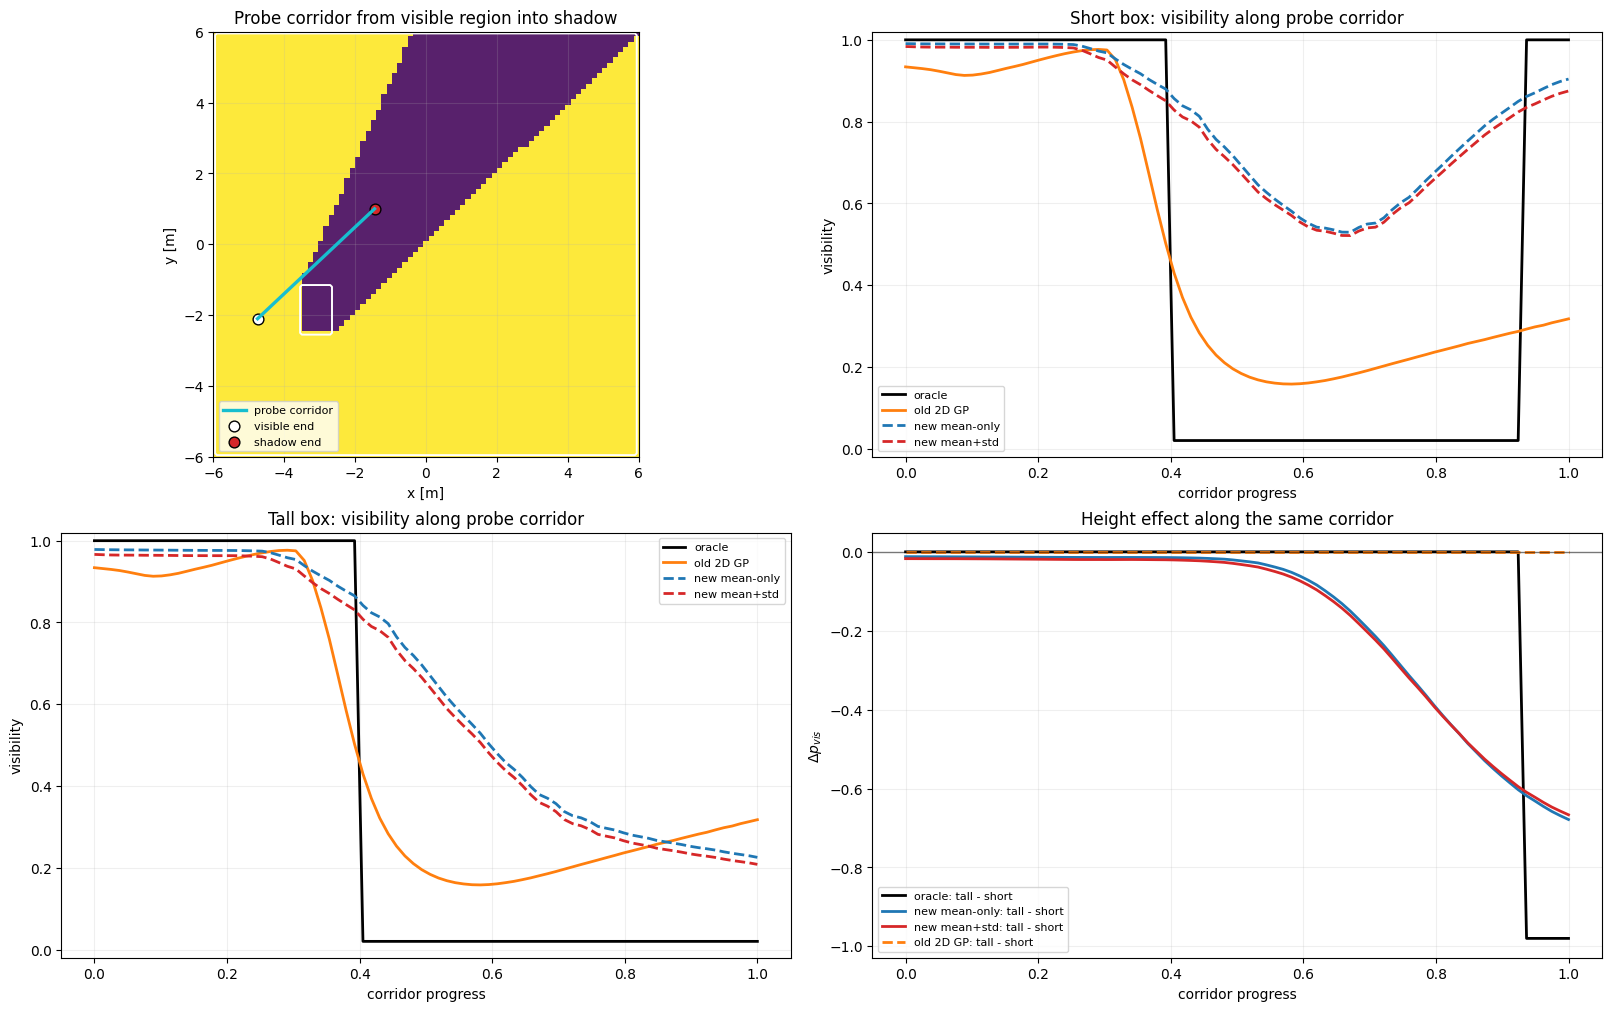

In [9]:
fig = helper.plot_probe_corridor(ctx)
plt.show()

## From occlusion handling to EFE planning

This is the central connection to the navigation stack.

The visibility prior does **not** act directly on the robot state.  
Instead, it changes the **effective observation model**.

### Clean planner mechanism

The clean planner mechanism is to work with an effective visibility scalar derived from the predicted belief. Ideally this is the belief-averaged quantity

$$
 \bar p_{\mathrm{vis},k}
 =
 \mathbb{E}_{z_k \sim \mathcal{N}(m_k,S_k)}\big[p_{\mathrm{vis}}(z_k)\big],
$$

which is then planner-shaped as

$$
 p_{\mathrm{vis,eff}}(x) = \bar p_{\mathrm{vis},k}^{\alpha}.
$$

The current compact implementation still approximates $\bar p_{\mathrm{vis},k}$ by a map lookup at the predicted mean state $m_k$, but the intended interpretation is belief-aware rather than mean-only.

This is followed by

$$
 R_{\mathrm{plan}}(x)
 =
 p_{\mathrm{vis,eff}}(x)\, R_{\mathrm{visible}}
 +
 \big(1 - p_{\mathrm{vis,eff}}(x)\big)\, R_{\mathrm{miss}}.
$$

Interpretation:

- the GP and raycasting change the visibility field,
- the predicted belief induces an effective visibility scalar,
- that effective visibility changes the expected observation noise model,
- the expected observation noise model changes the EFE objective.

This keeps the stack-level story clean:

> occlusion influences planning only through the planner's expected observation model.

### Posterior predictive moments

Given the predicted belief $\mathcal{N}(m_k, S_k)$ and the nonlinear camera map, the planner forms approximate observation moments

$$
 (\mu_k, \Sigma_k, \Gamma_k)
$$

using ET1 or ET2. In the compact experiments here, the active planner uses **ET2**.

### Ambiguity term

The local ambiguity depends on the conditional observation covariance

$$
 \Sigma_{\mathrm{cond}}
 =
 \Sigma_k - \Gamma_k^\top S_k^{-1} \Gamma_k.
$$

This enters through

$$
 \mathcal{H}(o_k \mid z_k)
 \approx
 \frac{1}{2}
 \left(
 d\log(2\pi e) + \log|\Sigma_{\mathrm{cond}}|
 \right).
$$

If visibility decreases, $R_{\mathrm{plan}}$ grows, the predicted observation covariance grows, and the ambiguity term changes.

### Risk term

The planner also compares the predicted observation distribution against a goal preference distribution. In implementation this is a KL-style risk term between the predicted observation Gaussian and the goal observation Gaussian.

### Discounted EFE objective

The compact planner therefore minimizes a discounted objective of the form

$$
 \mathcal{J}(u_{1:T})
 =
 \sum_{t=1}^{T} \gamma^t
 \left(
 \lambda_{\mathrm{risk}}\, \mathcal{R}_t
 +
 \lambda_{\mathrm{amb}}\, \mathcal{A}_t
 +
 \eta\, \|u_t\|^2
 \right),
$$

where the occlusion model influences the planner only through $p_{\mathrm{vis,eff}}(x)$ and therefore through $R_{\mathrm{plan}}(x)$.


## Online correction

The offline prior is only the first visibility estimate. The clean interpretation of the second stage is **calibration**, not online map learning: we observe whether detections succeed or fail and use those counts to adjust the prior in opacity space without retraining the GP.

A simple count-based calibration view is

$$
 p_{\mathrm{emp}}(x)
 =
 \frac{N_{\mathrm{detect}}(x)+a}{N_{\mathrm{seen}}(x)+a+b},
 \qquad
 A_{\mathrm{emp}}(x) = -\log p_{\mathrm{emp}}(x),
$$

followed by a confidence-weighted correction toward the empirical opacity estimate. In the current helper implementation this is approximated by a smoothed residual update,

$$
 A_{\mathrm{corr}}(x) = A_0(x) + \Delta_A(x),
 \qquad
 O_{\mathrm{corr}}(x) = \exp\big(-A_{\mathrm{corr}}(x)\big).
$$

In the canonical story notebook, correction is shown as a **second-pass calibration experiment**:

1. run once with the offline prior,
2. accumulate detection-based opacity residuals,
3. rerun planning with the corrected prior frozen.

That is easier to defend than learning and applying the correction inside the same episode because it cleanly separates:

- the offline GP prior,
- the detection-count calibration signal,
- the corrected planner behavior.


In [10]:
story_results = helper.run_story_experiments(ctx)
story_summary_df = helper.summarize_story_results(ctx, story_results)
display(story_summary_df.sort_values(['scene', 'method']))

,scene,method,final_true_goal_dist,mean_state_error,detection_rate,mean_p_vis_exec,mean_p_vis_plan,cum_risk,cum_ambiguity,final_trace
0,Short box,corrected prior,0.596209,0.046746,1.0,1.0,0.910791,4876.748929,1113.347825,0.038656
1,Short box,offline prior,3.943769,0.060009,1.0,1.0,0.909809,14826.418898,1125.217557,0.134596
2,Short box,old 2D GP,3.486732,0.065657,1.0,1.0,0.791284,15797.482247,1188.202730,0.046156
3,Tall box,corrected prior,1.186159,0.047680,1.0,1.0,0.856523,6438.916123,1164.066710,0.015120
4,Tall box,offline prior,0.957776,0.049294,1.0,1.0,0.842345,6447.796654,1173.265452,0.052924
5,Tall box,old 2D GP,3.563080,0.049610,1.0,1.0,0.863614,13862.273050,1153.397738,0.056259


## Compact planner comparison

These runs are still meant as a compact stack-level demonstration rather than a final benchmark, but they now support a cleaner interpretation:

- the planner mechanism is frozen to the visibility-aware observation model,
- the main comparison is **old 2D GP** versus **offline 2.5D prior**,
- the corrected prior is a genuine **second-pass rerun** rather than an in-episode adaptation,
- the diagnostic figures are meant to explain *why* the route changes, not only *that* it changes.

So this section should be read as:

- **planned paths**: where does each method choose to go?
- **effective planner visibility / risk / ambiguity**: which latent term is driving that choice?
- **belief diagnostics**: does occlusion visibly affect uncertainty and missed detections?
- **correction maps**: does calibration move the prior in a sensible direction?


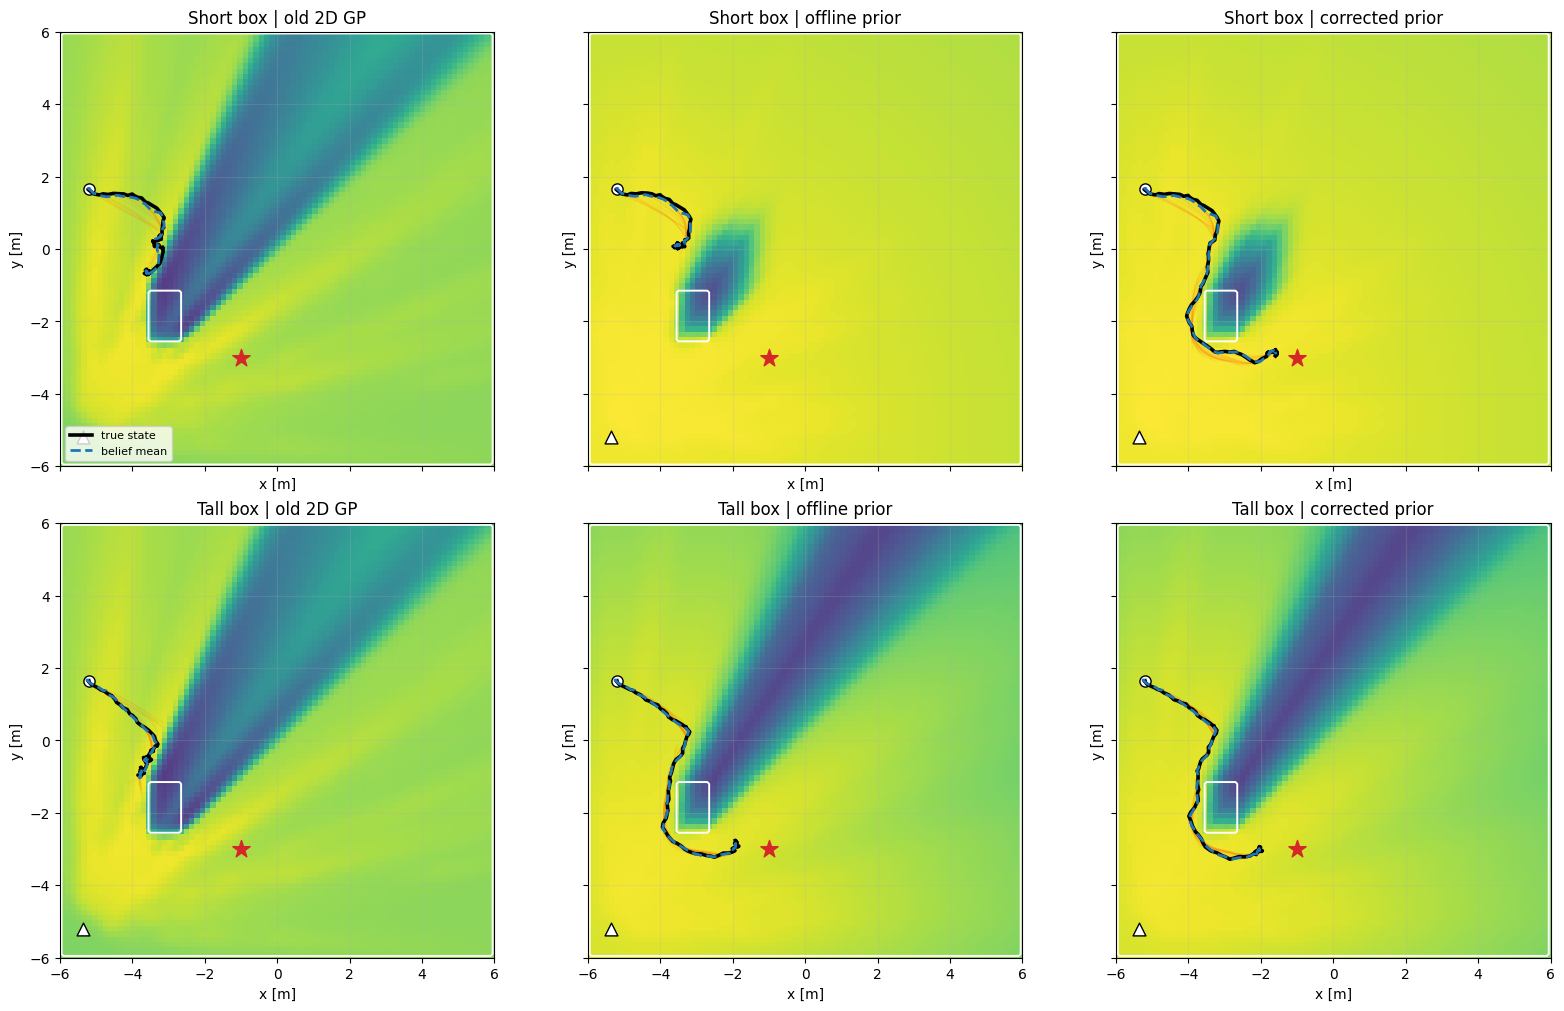

In [11]:
fig = helper.plot_story_paths(ctx, story_results)
plt.show()

### Risk and ambiguity diagnostics

The path plot shows the consequence of the optimization, but these traces show the mechanism.

- **Effective planner visibility** shows the visibility value after the planner-side shaping used to build the effective observation covariance.
- **Risk** tracks mismatch between the predicted observation distribution and the goal preference distribution.
- **Ambiguity** tracks the expected conditional observation uncertainty.
- **Planner objective** is the discounted combination of these terms under the current visibility-aware observation model.

So if a route looks conservative, this figure helps answer whether that conservatism came from low effective visibility, inflated observation noise, or a strong ambiguity contribution.


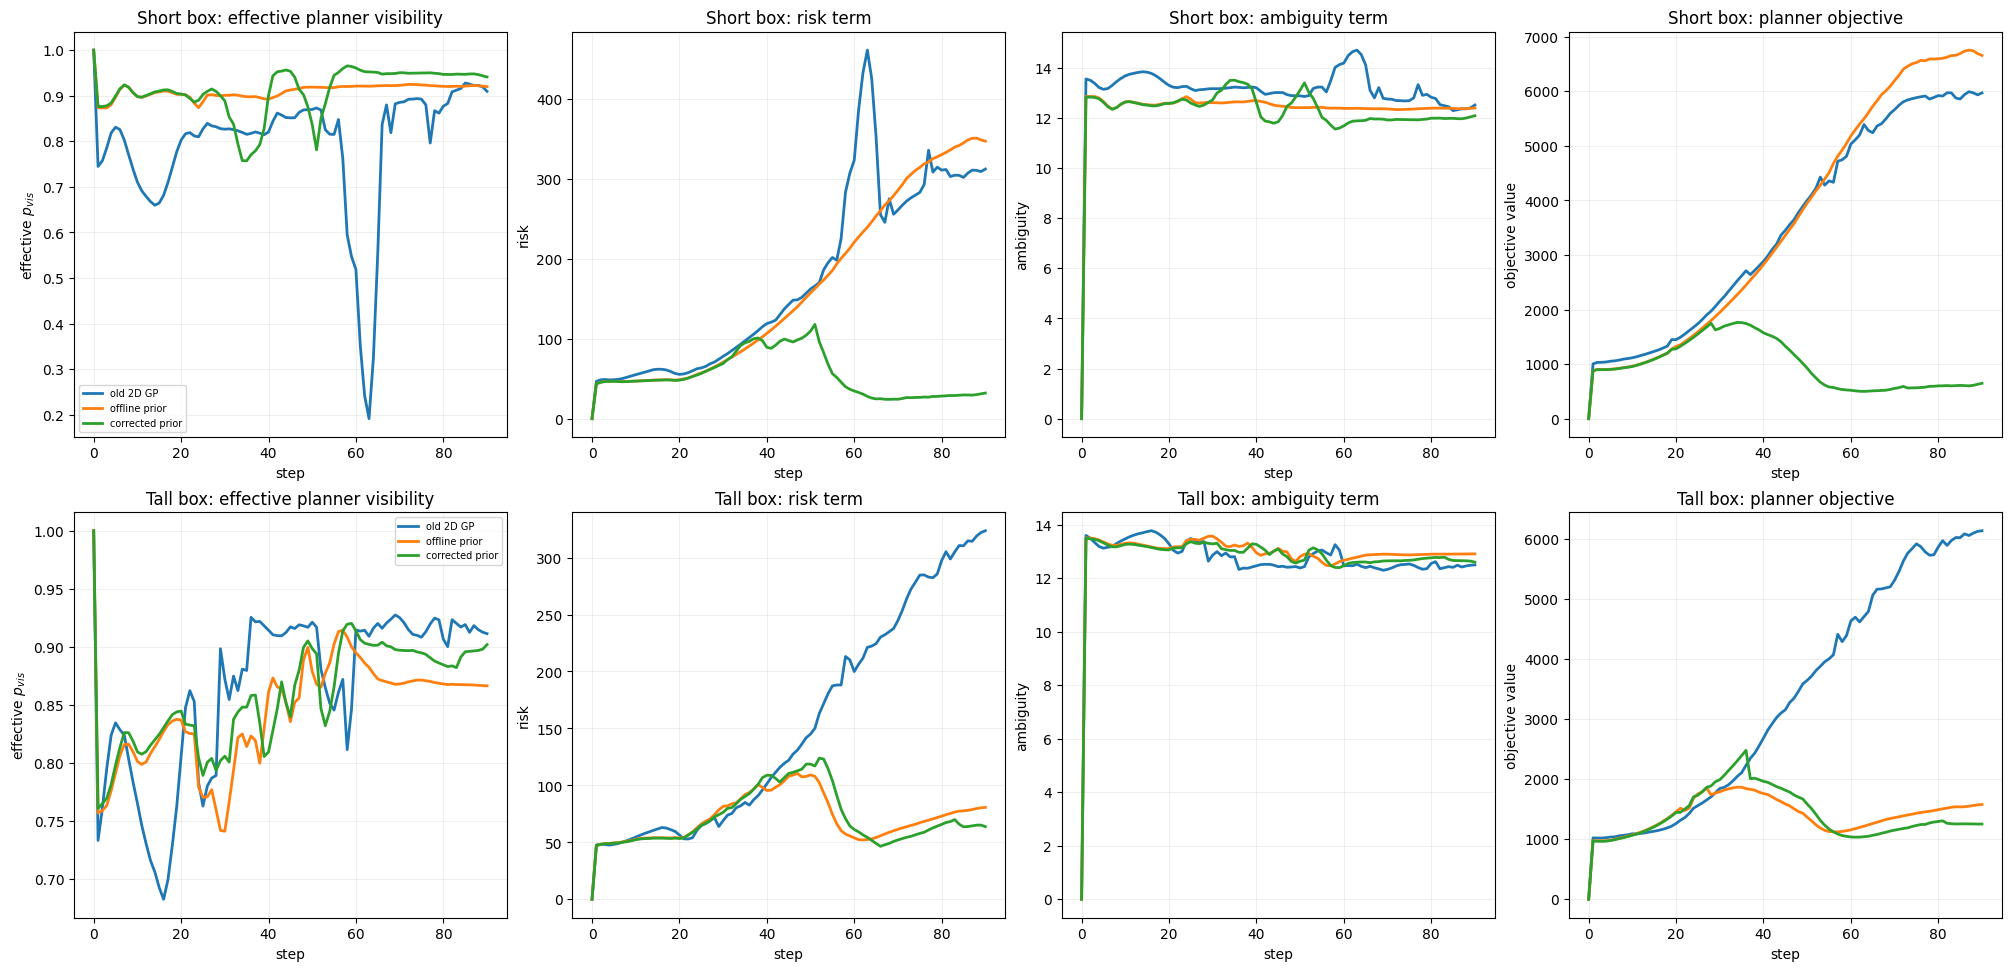

In [12]:
fig = helper.plot_story_risk_ambiguity(ctx, story_results)
plt.show()

### Belief impact under occlusion

Occlusion does not have to move the belief mean dramatically to matter. In this stack, the more direct effect is often on the **belief covariance**:

- the robot enters a low-visibility region,
- detections become less reliable or disappear,
- prediction dominates correction,
- covariance grows or remains elevated.

The figure below therefore plots $\mathrm{tr}(S_k)$ over time, shades intervals where execution visibility is low, and marks missed detections explicitly. This is the cleanest place to see whether occlusion is really changing the planner-relevant belief state.


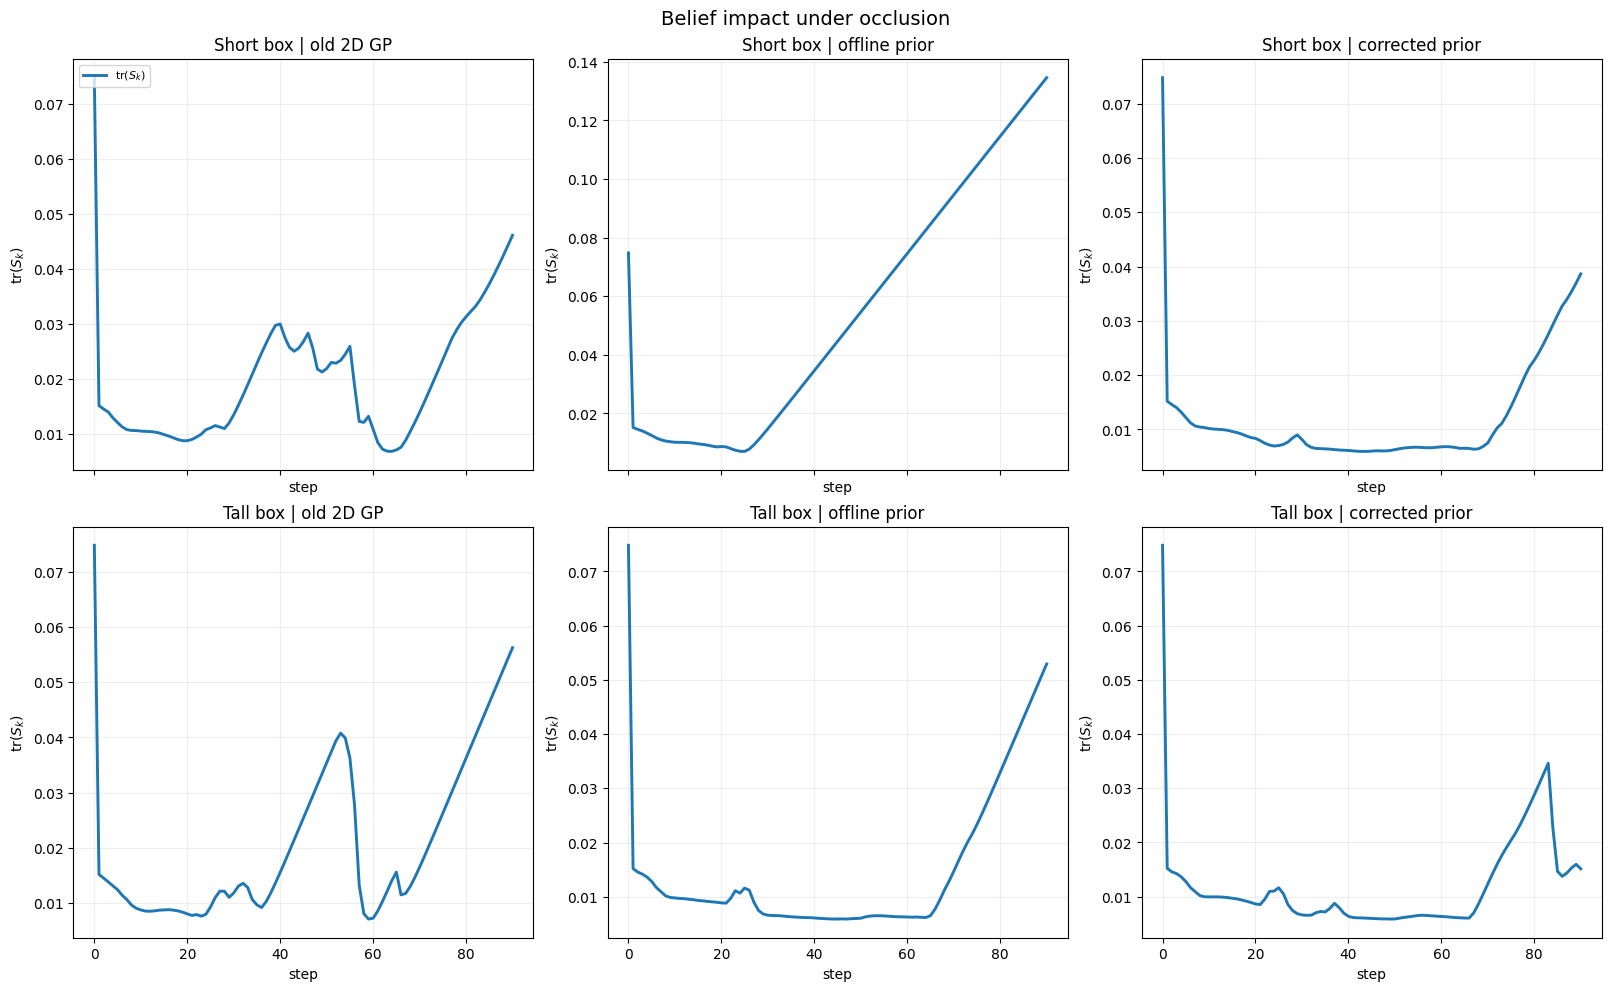

In [13]:
fig = helper.plot_story_belief_diagnostics(ctx, story_results)
plt.show()

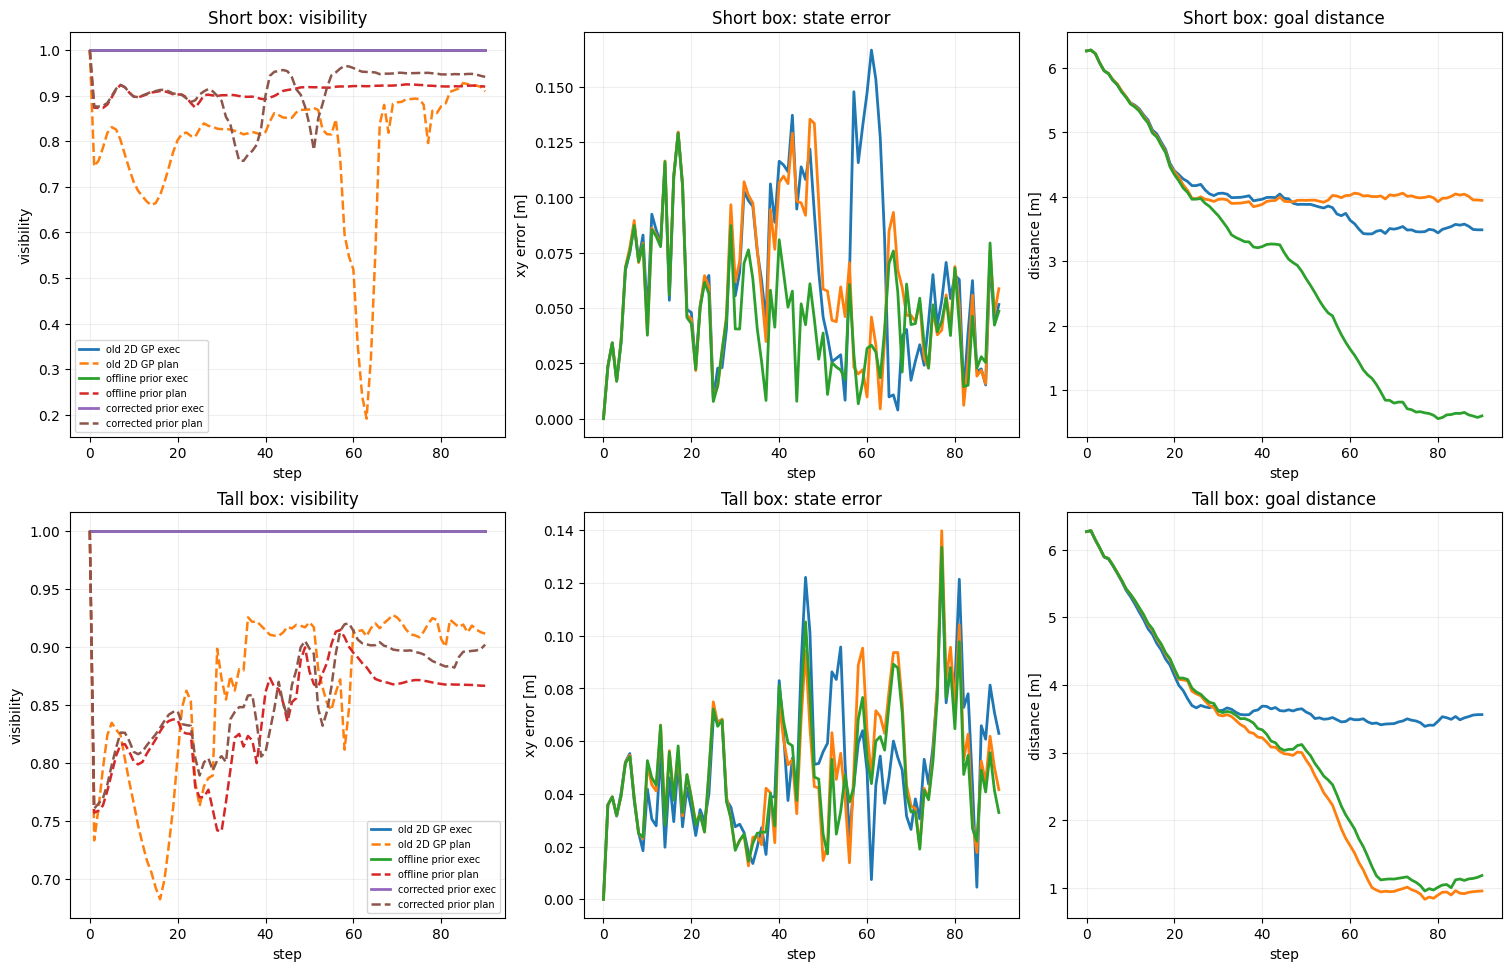

In [14]:
fig = helper.plot_story_timeseries(ctx, story_results)
plt.show()

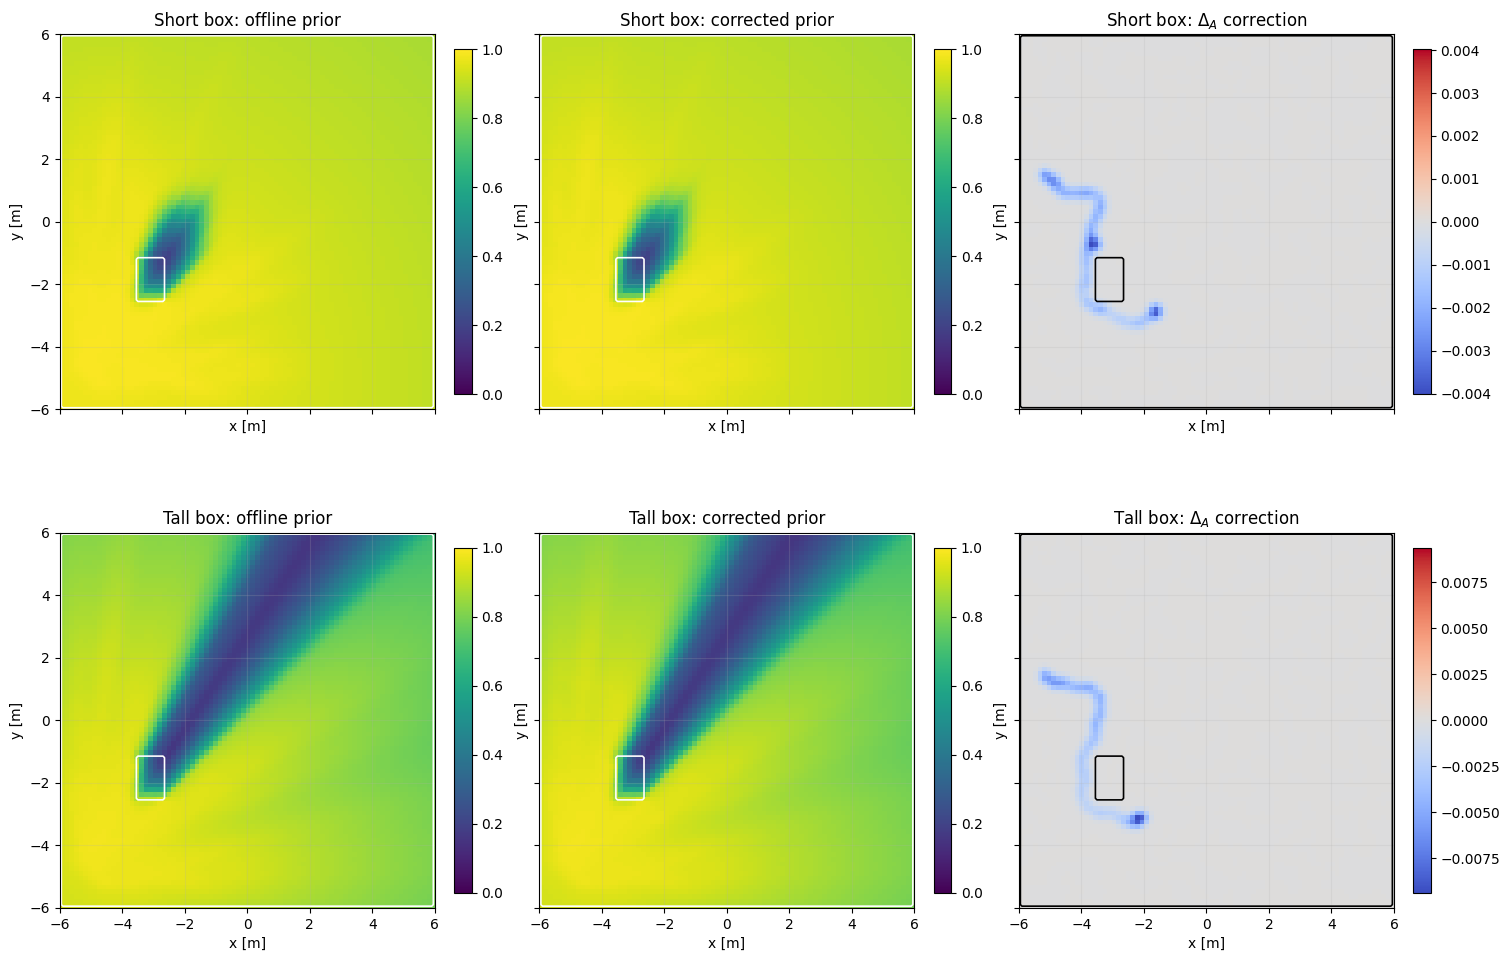

In [15]:
fig = helper.plot_story_correction_maps(ctx, story_results)
plt.show()

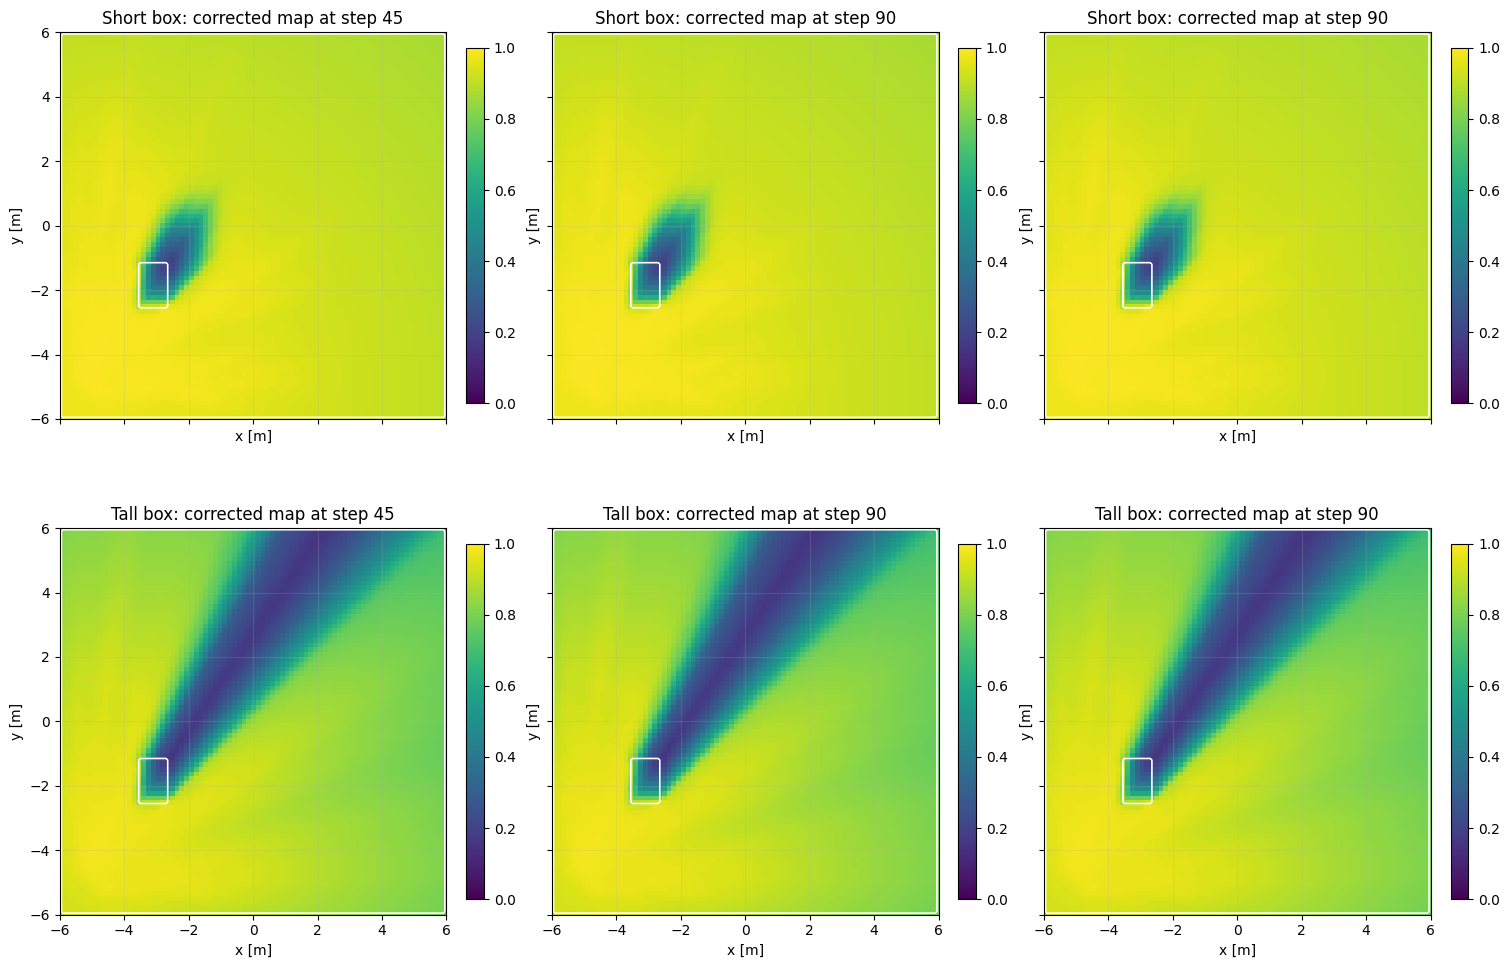

In [16]:
fig = helper.plot_story_correction_snapshots(ctx, story_results)
plt.show()

## Clean parameter sweep

Before changing the model again, it is useful to sweep only the parameters that preserve the clean stack story:

- `visibility_power`,
- `r_miss_uv`,
- `horizon`,
- `goal_tightening_power`.

The goal is not to maximize performance at any cost. The goal is to find the **smallest** settings that visibly change route choice without making the planner look artificial.

The sweep below focuses on the **Tall box** case with the offline prior, because that is where the occlusion effect is most informative.


,scene,parameter,value,baseline_value,final_goal_dist,mean_p_vis_plan,cum_risk,cum_ambiguity,final_trace
0,Tall box,goal_tightening_power,0.45,0.45,0.832212,0.845112,5506.385726,1171.700321,0.054346
1,Tall box,goal_tightening_power,0.60,0.45,3.450537,0.702840,15593.263933,1229.864643,0.139830
2,Tall box,goal_tightening_power,0.80,0.45,0.789864,0.842403,3705.947752,1173.218756,0.062177
3,Tall box,horizon,12.00,18.00,0.969922,0.859628,5518.627653,1162.673868,0.045603
4,Tall box,horizon,15.00,18.00,0.977880,0.857169,5743.346035,1164.564742,0.039739
5,Tall box,horizon,18.00,18.00,0.832212,0.845112,5506.385726,1171.700321,0.054346
6,Tall box,r_miss_uv,220.00,420.00,0.414682,0.759463,3498.145184,1087.380571,0.045198
7,Tall box,r_miss_uv,320.00,420.00,0.499009,0.818331,5079.232654,1135.090223,0.039046
8,Tall box,r_miss_uv,420.00,420.00,0.832212,0.845112,5506.385726,1171.700321,0.054346
9,Tall box,visibility_power,1.80,3.00,0.637846,0.886763,5289.327352,1142.043095,0.043243


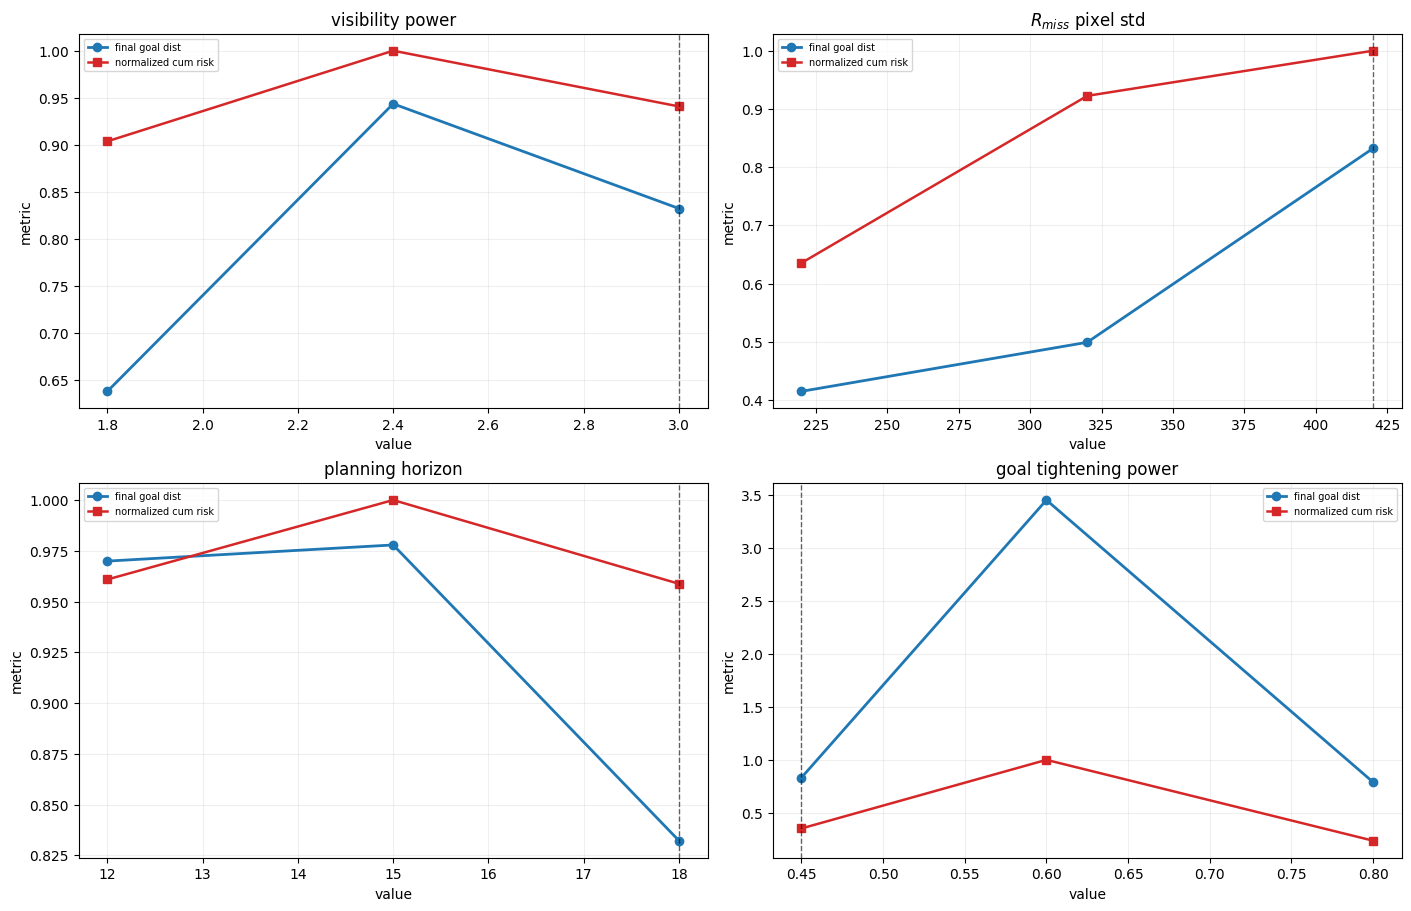

In [17]:
sweep_df = helper.run_clean_parameter_sweep(ctx)
display(sweep_df.sort_values(['parameter', 'value']).reset_index(drop=True))
fig = helper.plot_clean_parameter_sweep(sweep_df)
plt.show()

## Method decision

### What the notebook now argues

- **Old 2D GP** is the simplest baseline, but it misses obstacle height and therefore misrepresents the true shadow geometry.
- **2.5D ray-opacity prior** is the best current compromise because it keeps the planning story probabilistic while making the camera-to-obstacle geometry visible.
- The strongest near-term cleanup is to express the uncertainty-aware prior in **latent GP space** as $\sigma(\mu_f + \beta\sigma_f)$ rather than only as an output-space mean-plus-std proxy.
- The clean planner story is **belief-aware visibility**, even though the compact helper still uses a mean-state lookup as its first approximation.
- **Online correction** is most convincing as a calibration layer on top of the offline prior, not as the main source of the prior itself.
- **Full joint map-state uncertainty** remains future work, not the canonical implementation.

The implementation-summary tables below still reflect the current helper code, so they should be read alongside the three cleanup points above rather than as a contradiction of them.

### Decision criteria

The method is worth keeping if the answer to these questions is yes:

- does the prior change route choice in the Tall box case?
- does it do so through the observation model rather than through ad hoc penalties?
- does the corrected prior improve over the offline prior in a repeat run?
- is the explanation clean enough to defend to a supervisor?


In [18]:
display(helper.build_design_choices_table())
display(helper.build_implementation_options_table())
display(helper.build_limitations_table())


,Choice,Why,Benefit,Limitation
0,Shared 2D GP field for both box heights,Separates map learning from 3D ray geometry so...,Makes the 3D effect easy to defend visually.,The GP itself still does not encode height.
1,Single observed target point on the robot,Keeps the raycasting story focused on one line...,Cleaner derivation and plots.,Does not capture multi-feature perception effe...
2,Distance-weighted ray opacity sum,Treats visibility as accumulated transmittance...,Longer or more blocked rays reduce visibility ...,"Still a discretized approximation, not a full ..."
3,Soft height gate instead of hard cutoff,Avoids brittle on/off changes when the ray gra...,Smoother maps and more planner-friendly gradie...,Introduces a tunable parameter $\tau_z$ that n...
4,Online correction in opacity space,Keeps the transmittance story intact while ada...,Supports a clean two-pass calibration story wi...,Correction still relies on a heuristic residua...


,Method,Formula,Height aware,Uses GP std,Online correction,Best use
0,Hard 3D oracle raycast,segment-AABB intersection,Yes,No,No,ground-truth reference
1,Old 2D GP mean-occupancy,"$\exp(-\\tau \\, \\mathrm{mean}(p_{occ}))$",No,No,No,historical baseline
2,2.5D mean-only opacity prior,$O_0(x)=\exp(-\sum \Delta s_i g(z_i)\rho_{mean...,Yes,No,No,clean geometry-first prior
3,2.5D uncertainty-aware opacity prior,$O_0(x)=\exp(-\sum \Delta s_i g(z_i)(\rho_{mea...,Yes,Yes,No,defensive offline planner prior
4,Opacity-corrected prior,"$A_{corr}(x)=A_0(x)+\Delta_A(x),\; O_{corr}(x)...",Yes,Yes,Yes,second-pass calibration without GP retraining


,Limitation,Why it matters,Consequence
0,Map is still fundamentally 2D,Height enters through ray geometry and box hei...,"Good for controlled Gazebo transfer, not full ..."
1,"Soft height gate is modeled, not measured",The gate slope is a design choice.,The transition around the box top is interpret...
2,Online correction is residual-only,The runtime learner adjusts opacity but does n...,"Fast and practical, but limited if the offline..."
3,Single target point,Real heading estimation often depends on multi...,Good for explaining raycasting; simplified for...
4,No joint map-state uncertainty in the canonica...,Planner covariance does not change visibility ...,"That remains future work, not the main supervi..."


## Future work note

Before moving to full joint map-state uncertainty, there are three immediate cleanups that strengthen the current notebook story without changing its overall architecture:

- define the uncertainty-aware prior in latent GP space as $\sigma(\mu_f + \beta\sigma_f)$,
- replace the mean-state planner visibility lookup by an approximation to $\mathbb{E}[p_{\mathrm{vis}}(z_k)]$ under the predicted belief,
- treat the second pass explicitly as count-based calibration in opacity space.

The larger extension beyond that is **joint map-state uncertainty**:

- keep the GP field uncertain,
- keep the robot state uncertain,
- propagate both through the ray-opacity and visibility pipeline.

That is intentionally out of scope for this canonical notebook.

The current notebook therefore stops at:

- nonlinear camera observation modeling,
- GP-based offline visibility prior,
- visibility-aware EFE planning,
- second-pass calibration-style opacity correction,
- and a method decision about whether this compromise is good enough.
